Data Acquisition and Understanding

In [85]:
import argparse
import os
import sys
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import seaborn as sns
from datetime import datetime
df = pd.read_csv("data.csv" ,sep=',')


In [86]:
df

,website_id,title,price,currency,city,zone,property_type,transaction_type,surface_m2,rooms,bathrooms,description,agency_owner,phone,listing_url,data_hash,image_urls,published_date,scraped_at
0,698b18a6c43bfefaf2694c1e,À vendre appartement S+2 Ain Zaghouan Nord - 1...,1.0,TND,Tunis,NaN,NaN,NaN,115,0,0,NaN,NaN,NaN,https://century21.tn/property/a-vendre-apparte...,4262fa565db01f790e98080dc698ec35,['https://century21.tn/wp-content/uploads/What...,NaN,2026-02-10 21:01:31
1,698b18a6c43bfefaf2694c1e,À vendre duplex S+3 Jardins de Carthage - 307 m²,1.0,TND,Tunis,NaN,NaN,NaN,307,0,0,NaN,NaN,NaN,https://century21.tn/property/a-vendre-duplex-...,b9b8581e5189e7059877a8424d47a018,['https://century21.tn/wp-content/uploads/What...,NaN,2026-02-10 21:01:35
2,698b18a6c43bfefaf2694c1e,À vendre appartement S+2 La Soukra - 113 m²,1.0,TND,Tunis,NaN,NaN,NaN,113,0,0,NaN,NaN,NaN,https://century21.tn/property/a-vendre-apparte...,9e6f5b4dbc3b7ae4834b8ee301439a5d,['https://century21.tn/wp-content/uploads/c704...,NaN,2026-02-10 21:01:38
3,698b18a6c43bfefaf2694c1e,À louer appartement S+1 Jardins de Carthage - ...,1.0,TND,Tunis,NaN,NaN,NaN,70,0,0,NaN,NaN,NaN,https://century21.tn/property/a-louer-appartem...,966662ff763dd3242f0ad6cf65bbe7e4,['https://century21.tn/wp-content/uploads/What...,NaN,2026-02-10 21:01:41
4,698b18a6c43bfefaf2694c1e,À louer appartement S+3 cité les palmeraies - ...,1.0,TND,Tunis,NaN,NaN,NaN,167,0,0,NaN,NaN,NaN,https://century21.tn/property/a-louer-appartem...,b58a638329cd93161a959c867b1d33c0,['https://century21.tn/wp-content/uploads/c704...,NaN,2026-02-10 21:01:44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2394,69921250b4db7c7155569966,Annonces Immobilieres Tunisie,0.0,TND,Tunis,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,https://tunisie-immobilier.online/tag/annonces...,63856cadc0ac61002a8e6c85d5d544a2,['https://tunisie-immobilier.online/wp-content...,NaN,2026-02-15 20:40:06
2395,69921250b4db7c7155569966,annonce tunisie immobilier,0.0,TND,Tunis,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,https://tunisie-immobilier.online/tag/annonce-...,299068168832dac132550c9cb2f45787,['https://tunisie-immobilier.online/wp-content...,NaN,2026-02-15 20:40:09
2396,69921250b4db7c7155569966,Annonces Immobilieres Tunisie,0.0,TND,Tunis,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,https://tunisie-immobilier.online/category/ann...,4a18cf41cee15099c742ca7b146341d5,['https://tunisie-immobilier.online/wp-content...,NaN,2026-02-15 20:40:15
2397,698b187e2d8bb745d22d2cc9,Parfum amir al arab,0.0,TND,Sfax,NaN,NaN,NaN,0,0,0,NaN,NaN,NaN,https://www.tayara.tn/item/produits-de-beaut%2...,561ffd9308d196e9f4f2f4eb8752173b,[],NaN,2026-02-15 20:40:37


In [87]:
df.shape

(2399, 19)

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2399 entries, 0 to 2398
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   website_id        2399 non-null   object 
 1   title             2399 non-null   object 
 2   price             2399 non-null   float64
 3   currency          2399 non-null   object 
 4   city              1992 non-null   object 
 5   zone              0 non-null      float64
 6   property_type     0 non-null      float64
 7   transaction_type  0 non-null      float64
 8   surface_m2        2399 non-null   int64  
 9   rooms             2399 non-null   int64  
 10  bathrooms         2399 non-null   int64  
 11  description       320 non-null    object 
 12  agency_owner      0 non-null      float64
 13  phone             0 non-null      float64
 14  listing_url       2399 non-null   object 
 15  data_hash         2399 non-null   object 
 16  image_urls        2399 non-null   object 


In [89]:
df.describe()

,price,zone,property_type,transaction_type,surface_m2,rooms,bathrooms,agency_owner,phone,published_date
count,2.399000e+03,0.0,0.0,0.0,2399.000000,2399.000000,2399.0,0.0,0.0,0.0
mean,9.012966e+38,NaN,NaN,NaN,1152.705711,3.713214,0.0,NaN,NaN,NaN
std,4.414514e+40,NaN,NaN,NaN,14070.588842,50.072119,0.0,NaN,NaN,NaN
min,0.000000e+00,NaN,NaN,NaN,0.000000,0.000000,0.0,NaN,NaN,NaN
25%,0.000000e+00,NaN,NaN,NaN,8.500000,0.000000,0.0,NaN,NaN,NaN
50%,2.600000e+02,NaN,NaN,NaN,98.000000,1.000000,0.0,NaN,NaN,NaN
75%,3.550000e+03,NaN,NaN,NaN,218.000000,2.000000,0.0,NaN,NaN,NaN
max,2.162211e+42,NaN,NaN,NaN,600000.000000,1700.000000,0.0,NaN,NaN,NaN


In [90]:
df.isna().sum()

website_id             0
title                  0
price                  0
currency               0
city                 407
zone                2399
property_type       2399
transaction_type    2399
surface_m2             0
rooms                  0
bathrooms              0
description         2079
agency_owner        2399
phone               2399
listing_url            0
data_hash              0
image_urls             0
published_date      2399
scraped_at             0
dtype: int64

In [91]:
def show_table(title: str, frame: pd.DataFrame, head_only_if_big=True, limit=20):
    print(f"\n=== {title} ===")
    if head_only_if_big and len(frame) > 500:
        display(frame.head(limit))
        print(f"... ({len(frame)} rows total)")
    else:
        display(frame)

unique_counts = df.nunique(dropna=False)
unique_df = (
    pd.DataFrame({"unique_count_including_NaN": unique_counts})
    .rename_axis("column")
    .reset_index()
    .sort_values("unique_count_including_NaN", ascending=False)
)
show_table("04 - Unique counts per column", unique_df, head_only_if_big=False)


=== 04 - Unique counts per column ===


,column,unique_count_including_NaN
15,data_hash,2399
14,listing_url,2399
18,scraped_at,2331
1,title,1745
16,image_urls,1030
2,price,469
8,surface_m2,406
11,description,249
0,website_id,80
9,rooms,24


In [92]:
dupes = int(df.duplicated().sum())
show_table("07 - Duplicate row count", pd.DataFrame({"duplicate_rows":[dupes]}), head_only_if_big=False)


=== 07 - Duplicate row count ===


,duplicate_rows
0,0


In [93]:
print("\n  ┌─ MÉTHODE A : IQR (par variable) ─────────────────────")

iqr_results = {}
cols_iqr = [c for c in ["price", "surface_m2", "rooms"] if c in df.columns]

for col in cols_iqr:
    serie = df[col].dropna()
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr    = q3 - q1
    lo     = q1 - 1.5 * iqr
    hi     = q3 + 1.5 * iqr
    n_out  = ((serie < lo) | (serie > hi)).sum()
    pct    = n_out / len(serie) * 100
    iqr_results[col] = {"n": n_out, "pct": pct, "lo": lo, "hi": hi}
    bar = "█" * int(pct / 2)
    print(f"  │  {col:20s} → {n_out:4d} outliers ({pct:5.1f}%)  "
          f"Seuils [{lo:.0f} , {hi:.0f}]  {bar}")


  ┌─ MÉTHODE A : IQR (par variable) ─────────────────────
  │  price                →  558 outliers ( 23.3%)  Seuils [-5325 , 8875]  ███████████
  │  surface_m2           →  266 outliers ( 11.1%)  Seuils [-306 , 532]  █████
  │  rooms                →   71 outliers (  3.0%)  Seuils [-3 , 5]  █


In [95]:
pip install prince


Note: you may need to restart the kernel to use updated packages.


data preparation 

In [99]:
# ÉTAPE 1 — SUPPRIMER COLONNES VIDES + INUTILES
# ══════════════════════════════════════════════════════
print("\n── Étape 1 : Suppression colonnes ──")

# Colonnes 100% vides
cols_vides = [c for c in df.columns if df[c].isna().all()]
print(f"  100% vides   : {cols_vides}")
df.drop(columns=cols_vides, inplace=True)

# Colonnes à valeur unique (aucune info)
cols_unique = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
print(f"  Valeur unique : {cols_unique}")
df.drop(columns=cols_unique, inplace=True)


print(f"  → Shape : {df.shape}")


── Étape 1 : Suppression colonnes ──
  100% vides   : ['zone', 'property_type', 'transaction_type', 'agency_owner', 'phone', 'published_date']
  Valeur unique : ['currency', 'bathrooms']
  → Shape : (2399, 11)


In [100]:
# ÉTAPE 2 — SUPPRIMER / CORRIGER LES LIGNES NaN
# ══════════════════════════════════════════════════════
print("\n── Étape 2 : Valeurs manquantes ──")
print(f"  NaN avant :\n{df.isna().sum()[df.isna().sum() > 0]}")

# Colonnes numériques → médiane
for col in df.select_dtypes(include=np.number).columns:
    n = df[col].isna().sum()
    if n > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  {col} : {n} NaN → médiane ({df[col].median():.1f})")

# Colonnes catégorielles → "Inconnu"
for col in df.select_dtypes(include="object").columns:
    n = df[col].isna().sum()
    if n > 0:
        df[col].fillna("Inconnu", inplace=True)
        print(f"  {col} : {n} NaN → 'Inconnu'")

print(f"  NaN restants : {df.isna().sum().sum()}")


── Étape 2 : Valeurs manquantes ──
  NaN avant :
city            407
description    2079
dtype: int64
  city : 407 NaN → 'Inconnu'
  description : 2079 NaN → 'Inconnu'
  NaN restants : 0


In [101]:
print("\n── Étape 3 : Outliers ──")

# Filtres métier d'abord
n = len(df)
df = df[df["price"] > 0]
df = df[df["price"] < 50_000_000]
if "surface_m2" in df.columns:
    df = df[df["surface_m2"] < 10_000]
print(f"  Filtres métier : supprimé {n - len(df)} lignes")

# Isolation Forest sur colonnes numériques clés
# Remplacer les outliers par clip IQR (pas de suppression)
for col in ["price", "surface_m2", "rooms"]:
    if col not in df.columns:
        continue
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr    = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out  = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lower=lo, upper=hi)
    print(f"  {col} : {n_out} outliers remplacés par clip [{lo:.0f}, {hi:.0f}]")


── Étape 3 : Outliers ──
  Filtres métier : supprimé 960 lignes
  price : 179 outliers remplacés par clip [-361075, 603045]
  surface_m2 : 140 outliers remplacés par clip [-350, 690]
  rooms : 38 outliers remplacés par clip [-3, 5]


In [102]:
# ÉTAPE 4 — STANDARDISER LES TYPES
# ══════════════════════════════════════════════════════
print("\n── Étape 4 : Types ──")

# Convertir colonnes object en minuscules
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip().str.lower()
    print(f"  {col} → minuscules, espaces supprimés")

# Forcer types numériques
for col in ["price", "surface_m2", "rooms"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"\n  Types finaux :")
print(df.dtypes.to_string())


── Étape 4 : Types ──
  website_id → minuscules, espaces supprimés
  title → minuscules, espaces supprimés
  city → minuscules, espaces supprimés
  description → minuscules, espaces supprimés
  listing_url → minuscules, espaces supprimés
  data_hash → minuscules, espaces supprimés
  image_urls → minuscules, espaces supprimés
  scraped_at → minuscules, espaces supprimés

  Types finaux :
website_id      object
title           object
price          float64
city            object
surface_m2       int64
rooms            int64
description     object
listing_url     object
data_hash       object
image_urls      object
scraped_at      object


In [103]:
# ÉTAPE 5 — FEATURE ENGINEERING
# ══════════════════════════════════════════════════════
print("\n── Étape 5 : Feature Engineering ──")

# Log-transformation (réduire asymétrie)
df["log_price"] = np.log1p(df["price"])
print("  log_price créé")

if "surface_m2" in df.columns:
    df["log_surface"] = np.log1p(df["surface_m2"])
    print("  log_surface créé")

# Prix par m²
if "surface_m2" in df.columns:
    df["price_per_m2"] = np.where(df["surface_m2"] > 0,
                                   df["price"] / df["surface_m2"], np.nan)
    df["price_per_m2"].fillna(df["price_per_m2"].median(), inplace=True)
    print("  price_per_m2 créé")

# Extraction depuis le titre
import re
if "title" in df.columns:
    def get_transaction(t):
        t = str(t).lower()
        if any(k in t for k in ["vendre", "vente"]): return "vente"
        if any(k in t for k in ["louer", "location"]): return "location"
        return "autre"

    def get_property(t):
        t = str(t).lower()
        for k, v in [("appartement","appartement"), ("villa","villa"),
                     ("maison","maison"), ("terrain","terrain"),
                     ("bureau","bureau"), ("studio","studio")]:
            if k in t: return v
        return "autre"

    df["transaction_type"] = df["title"].apply(get_transaction)
    df["property_type"]    = df["title"].apply(get_property)
    print("  transaction_type, property_type extraits du titre")


── Étape 5 : Feature Engineering ──
  log_price créé
  log_surface créé
  price_per_m2 créé
  transaction_type, property_type extraits du titre


Ces nouvelles features sont créées pour :

   Réduire l’effet des extrêmes (log_price, log_surface).

   Standardiser l’évaluation des biens (price_per_m2).
   
   Capturer des informations importantes du texte (transaction_type, property_type).

In [105]:
# ÉTAPE 6 — ENCODAGE + SPLIT + STANDARDISATION
# ══════════════════════════════════════════════════════
print("\n── Étape 6 : Encodage + Split + Standardisation ──")

# Encodage
CAT_COLS = [c for c in ["city", "property_type", "transaction_type"]
            if c in df.columns]
le = LabelEncoder()
for col in CAT_COLS:
    df[col + "_enc"] = le.fit_transform(df[col].astype(str))
    print(f"  {col} → {col}_enc")

# Sélection features finales
FEATURES = [c for c in ["price", "surface_m2", "rooms",
                          "log_price", "log_surface", "price_per_m2",
                          "city_enc", "property_type_enc", "transaction_type_enc"]
            if c in df.columns]

TARGET = "log_price"
df_model = df[FEATURES].dropna()

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

print(f"\n  X : {X.shape}  features : {X.columns.tolist()}")
print(f"  y : {TARGET}")

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n  Train : {X_train.shape[0]} lignes")
print(f"  Test  : {X_test.shape[0]} lignes")

# Standardisation (fit sur train seulement !)
NUM_SCALE = [c for c in ["price", "surface_m2", "rooms", "price_per_m2"]
             if c in X_train.columns]
scaler = StandardScaler()
X_train[NUM_SCALE] = scaler.fit_transform(X_train[NUM_SCALE])
X_test[NUM_SCALE]  = scaler.transform(X_test[NUM_SCALE])
print(f"  Standardisé : {NUM_SCALE}")




── Étape 6 : Encodage + Split + Standardisation ──
  city → city_enc
  property_type → property_type_enc
  transaction_type → transaction_type_enc

  X : (1439, 8)  features : ['price', 'surface_m2', 'rooms', 'log_surface', 'price_per_m2', 'city_enc', 'property_type_enc', 'transaction_type_enc']
  y : log_price

  Train : 1151 lignes
  Test  : 288 lignes
  Standardisé : ['price', 'surface_m2', 'rooms', 'price_per_m2']


In [106]:
# ══════════════════════════════════════════════════════
# RÉSUMÉ
# ══════════════════════════════════════════════════════
print("\n" + "="*50)
print("RÉSUMÉ FINAL")
print("="*50)
print(f"  Lignes finales : {len(df_model)}")
print(f"  Features       : {X.columns.tolist()}")
print(f"  Target         : {TARGET}")
print(f"  Train / Test   : {X_train.shape[0]} / {X_test.shape[0]}")
print("\n→ Prêt pour la modélisation ✅")

# Export
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv",   index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv",   index=False)


RÉSUMÉ FINAL
  Lignes finales : 1439
  Features       : ['price', 'surface_m2', 'rooms', 'log_surface', 'price_per_m2', 'city_enc', 'property_type_enc', 'transaction_type_enc']
  Target         : log_price
  Train / Test   : 1151 / 288

→ Prêt pour la modélisation ✅


── OUTLIERS (IQR) ──
  price           →    0 outliers (0.0%)  [-361075 , 603045]
  surface_m2      →    0 outliers (0.0%)  [-350 , 690]
  rooms           →    0 outliers (0.0%)  [-3 , 5]
  price_per_m2    →  205 outliers (14.2%)  [-1296 , 2176]


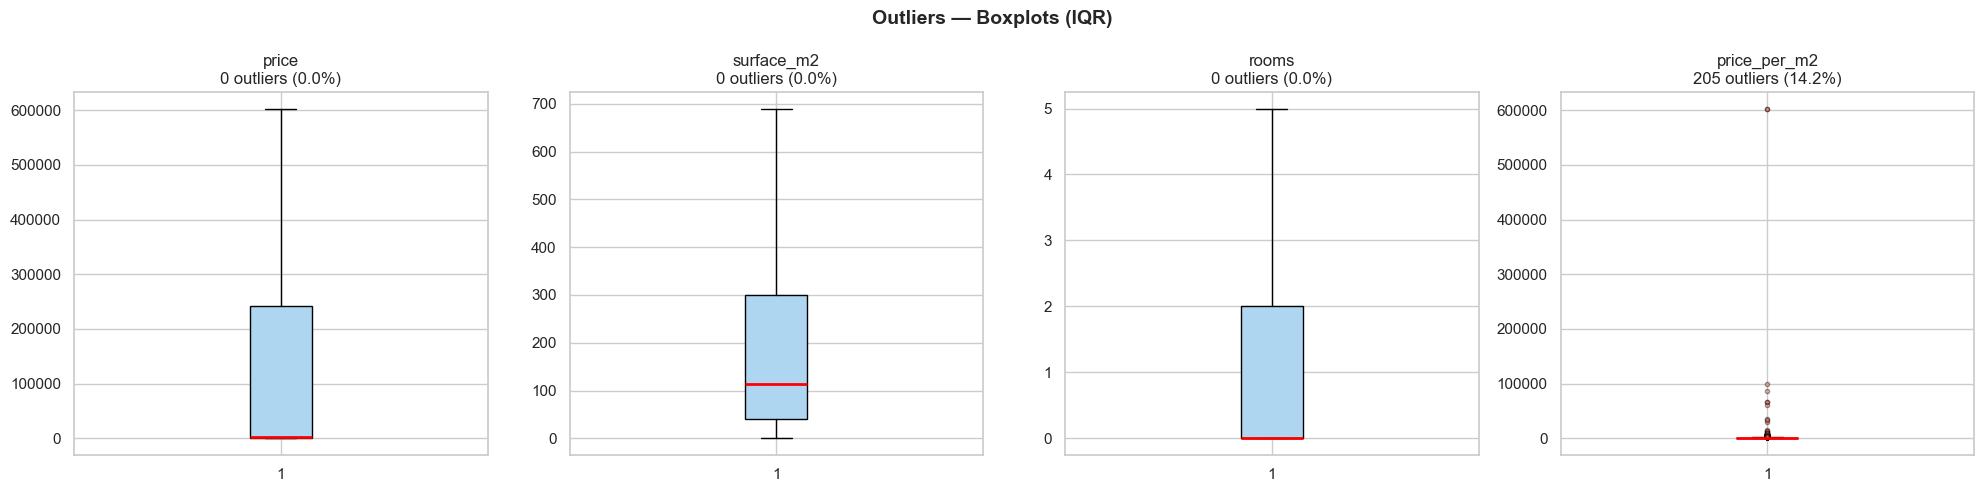

In [108]:
NUM_COLS = [c for c in ["price", "surface_m2", "rooms", "price_per_m2"]
            if c in df.columns]
CAT_COLS = [c for c in ["transaction_type", "property_type", "city"]
            if c in df.columns]

# ══════════════════════════════════════════════════════
# 1. DÉTECTION OUTLIERS — IQR
# ══════════════════════════════════════════════════════

print("── OUTLIERS (IQR) ──")
iqr_results = {}
for col in NUM_COLS:
    serie      = df[col].dropna()
    q1, q3     = serie.quantile(0.25), serie.quantile(0.75)
    iqr        = q3 - q1
    lo, hi     = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out      = ((serie < lo) | (serie > hi)).sum()
    pct        = n_out / len(serie) * 100
    iqr_results[col] = {"n": n_out, "pct": pct, "lo": lo, "hi": hi}
    print(f"  {col:15s} → {n_out:4d} outliers ({pct:.1f}%)  [{lo:.0f} , {hi:.0f}]")

# Boxplots outliers
fig, axes = plt.subplots(1, len(NUM_COLS), figsize=(5 * len(NUM_COLS), 5))
fig.suptitle("Outliers — Boxplots (IQR)", fontsize=14, fontweight="bold")
for ax, col in zip(axes, NUM_COLS):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor="#AED6F1"),
               medianprops=dict(color="red", lw=2),
               flierprops=dict(marker="o", markersize=3, alpha=0.4,
                               markerfacecolor="tomato"))
    ax.set_title(f"{col}\n{iqr_results[col]['n']} outliers ({iqr_results[col]['pct']:.1f}%)")
plt.tight_layout()
plt.show()

PCA


ACP — Variance expliquée :
  PC1 : 33.1%   cumulé 33.1%
  PC2 : 26.0%   cumulé 59.0%
  PC3 : 25.2%   cumulé 84.2%
  PC4 : 15.8%   cumulé 100.0%
→ 3 composantes pour 80% de variance


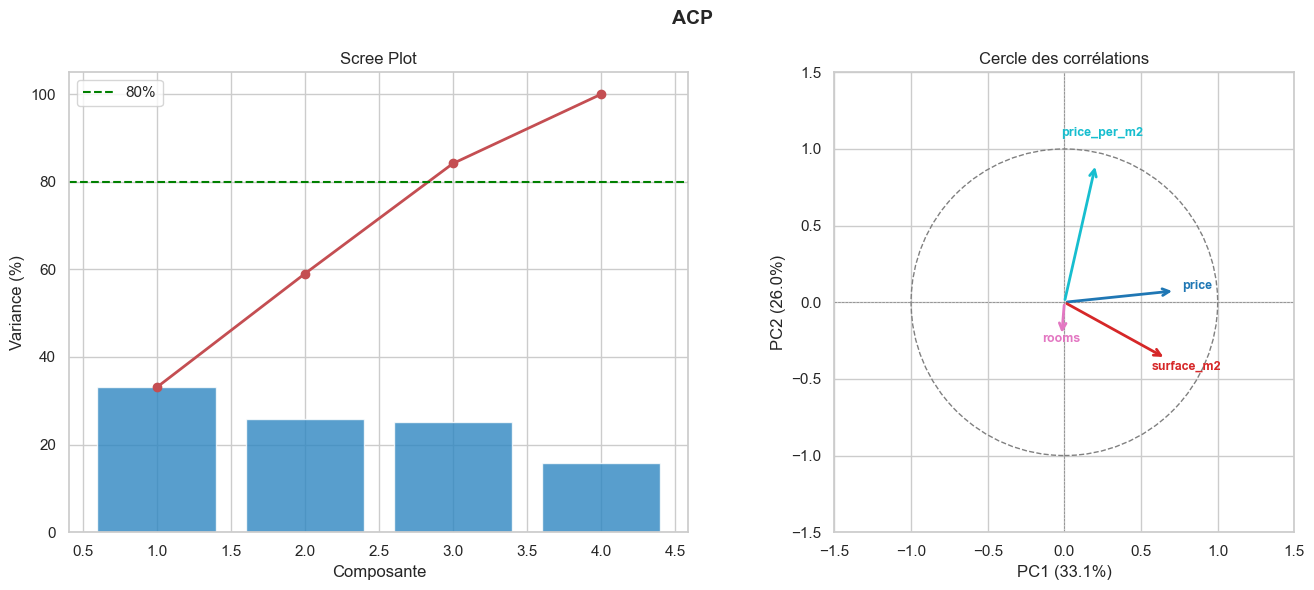

In [111]:
X_num = StandardScaler().fit_transform(df[NUM_COLS])
pca_full = PCA().fit(X_num)
exp = pca_full.explained_variance_ratio_
cum = np.cumsum(exp)
n_comp = int(np.argmax(cum >= 0.80)) + 1
print("\nACP — Variance expliquée :")
for i, (e, c) in enumerate(zip(exp, cum)):
    print(f"  PC{i+1} : {e*100:.1f}%   cumulé {c*100:.1f}%")
print(f"→ {n_comp} composantes pour 80% de variance")

# Cercle des corrélations PCA
pca2 = PCA(n_components=2).fit(X_num)
X2 = pca2.transform(X_num)
load2 = pca2.components_.T
ev = pca2.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(14,6))
fig.suptitle("ACP", fontsize=14, fontweight="bold")

# Scree plot
axes[0].bar(range(1, len(exp)+1), exp*100, color="#2E86C1", alpha=0.8)
axes[0].plot(range(1, len(cum)+1), cum*100, "ro-", lw=2)
axes[0].axhline(80, color="green", ls="--", label="80%")
axes[0].set_xlabel("Composante"); axes[0].set_ylabel("Variance (%)")
axes[0].set_title("Scree Plot"); axes[0].legend()

# Cercle des corrélations
axes[1].add_patch(plt.Circle((0,0),1,fill=False,color="grey",ls="--"))
colors = plt.cm.tab10(np.linspace(0,1,len(NUM_COLS)))
for i, feat in enumerate(NUM_COLS):
    axes[1].annotate("", xy=(load2[i,0], load2[i,1]), xytext=(0,0),
                     arrowprops=dict(arrowstyle="->", color=colors[i], lw=2))
    axes[1].text(load2[i,0]*1.2, load2[i,1]*1.2, feat,
                 fontsize=9, color=colors[i], fontweight="bold", ha="center")
axes[1].axhline(0, color="grey", lw=0.5, ls="--")
axes[1].axvline(0, color="grey", lw=0.5, ls="--")
axes[1].set_xlim(-1.5,1.5); axes[1].set_ylim(-1.5,1.5)
axes[1].set_aspect("equal")
axes[1].set_xlabel(f"PC1 ({ev[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
axes[1].set_title("Cercle des corrélations")
plt.tight_layout()
plt.show()

ACM

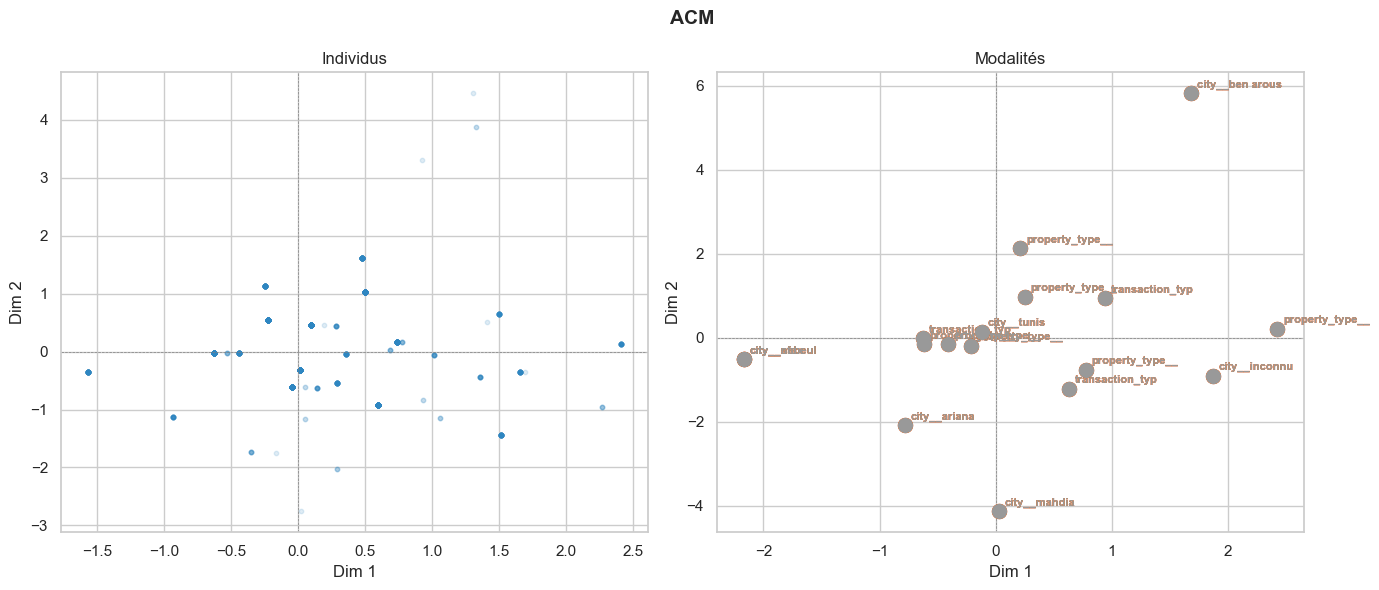

In [112]:
CAT_COLS = [c for c in ["transaction_type", "property_type", "city"] if c in df.columns]

if 'prince' in globals():
    df_acm = df[CAT_COLS].fillna("inconnu").astype(str)
    mca = prince.MCA(n_components=2, random_state=42)
    mca.fit(df_acm)
    rows = mca.row_coordinates(df_acm)
    cols_acm = mca.column_coordinates(df_acm)

    fig, axes = plt.subplots(1,2,figsize=(14,6))
    fig.suptitle("ACM", fontsize=14, fontweight="bold")

    # Individus
    axes[0].scatter(rows.iloc[:,0], rows.iloc[:,1], alpha=0.15, s=10, color="#2E86C1")
    axes[0].axhline(0,color="grey",lw=0.5,ls="--"); axes[0].axvline(0,color="grey",lw=0.5,ls="--")
    axes[0].set_xlabel("Dim 1"); axes[0].set_ylabel("Dim 2"); axes[0].set_title("Individus")

    # Modalités
    colors_cat = plt.cm.Set1(np.linspace(0,1,len(CAT_COLS)))
    for i, var in enumerate(CAT_COLS):
        for idx in cols_acm.index:
            x, y = cols_acm.loc[idx].iloc[0], cols_acm.loc[idx].iloc[1]
            axes[1].scatter(x, y, s=100, color=colors_cat[i], zorder=5)
            axes[1].annotate(str(idx)[:15], (x,y), fontsize=8,
                             xytext=(4,4), textcoords="offset points",
                             color=colors_cat[i], fontweight="bold")
    axes[1].axhline(0,color="grey",lw=0.5,ls="--"); axes[1].axvline(0,color="grey",lw=0.5,ls="--")
    axes[1].set_xlabel("Dim 1"); axes[1].set_ylabel("Dim 2"); axes[1].set_title("Modalités")
    plt.tight_layout(); plt.show()


boxplot pour les variables numeriques 

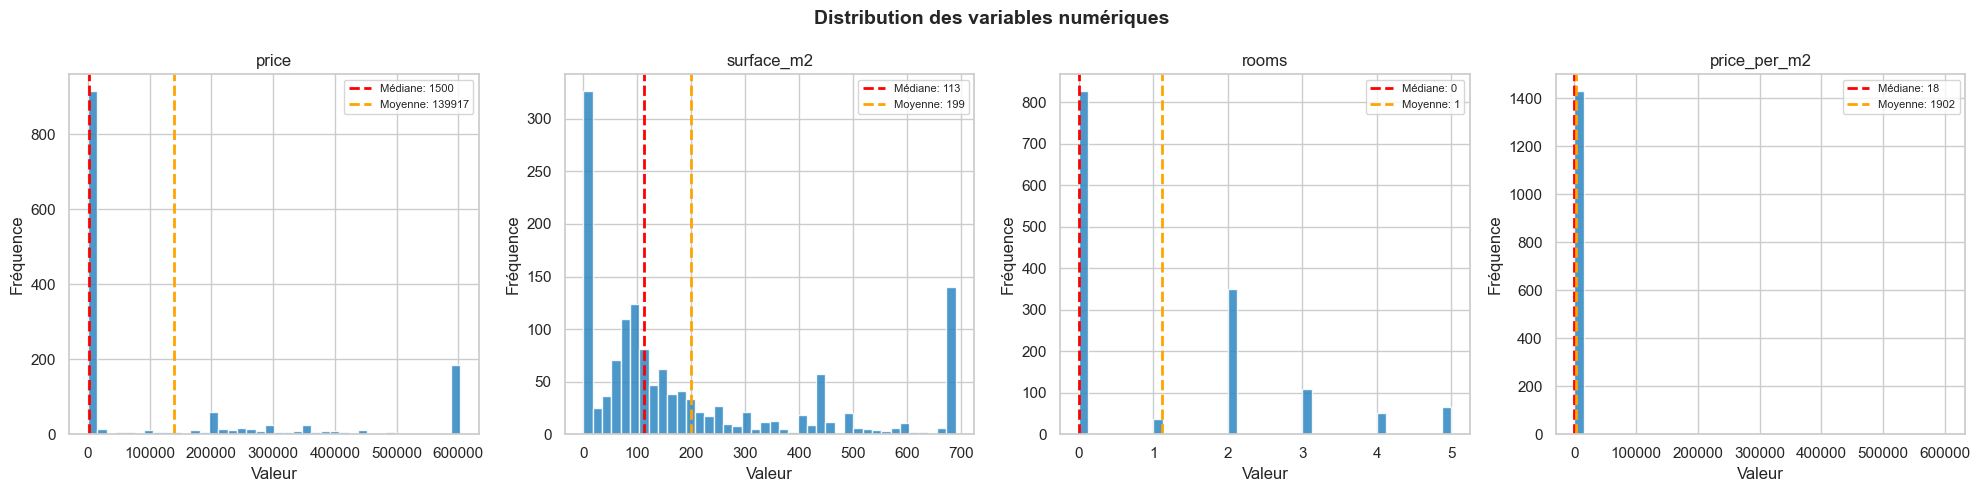

In [113]:
fig, axes = plt.subplots(1, len(NUM_COLS), figsize=(5*len(NUM_COLS),5))
fig.suptitle("Distribution des variables numériques", fontsize=14, fontweight="bold")
for ax, col in zip(axes, NUM_COLS):
    data = df[col]
    ax.hist(data, bins=40, color="#2E86C1", edgecolor="white", alpha=0.85)
    ax.axvline(data.median(), color="red", lw=2, ls="--", label=f"Médiane: {data.median():.0f}")
    ax.axvline(data.mean(), color="orange", lw=2, ls="--", label=f"Moyenne: {data.mean():.0f}")
    ax.set_title(col); ax.set_xlabel("Valeur"); ax.set_ylabel("Fréquence")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

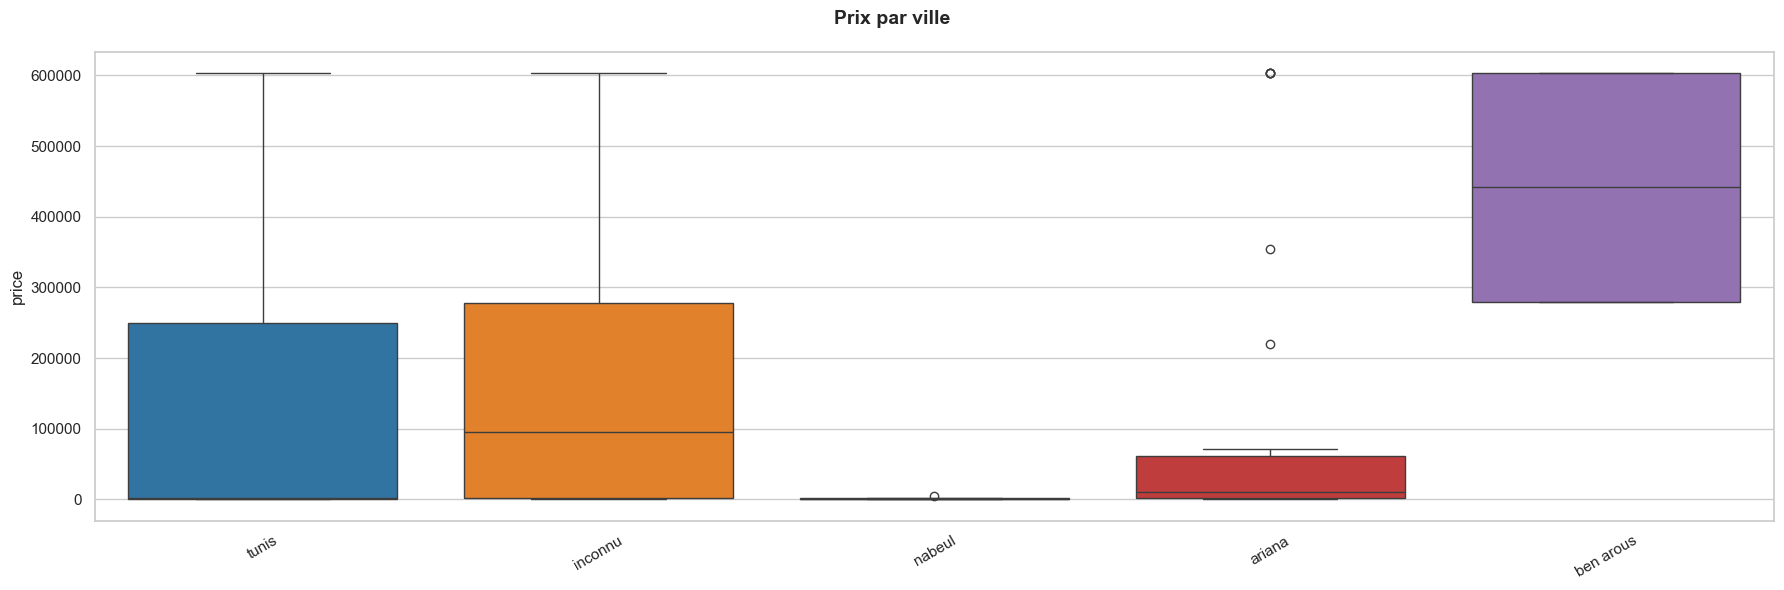

In [114]:
# Boxplots par ville
top_cities = df["city"].value_counts().head(5).index
df_city = df[df["city"].isin(top_cities)]
fig, ax = plt.subplots(figsize=(18,6))
fig.suptitle("Prix par ville", fontsize=14, fontweight="bold")
sns.boxplot(data=df_city, x="city", y="price", palette="tab10", ax=ax)
ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

In [115]:
# Nécessite openpyxl ou xlwt
df.to_excel("data_cleaned.xlsx", index=False)
print("✅ Dataset enregistré en Excel : data_cleaned.xlsx")

✅ Dataset enregistré en Excel : data_cleaned.xlsx
